44) sklearn 전처리 - 변수변환(분포변환)

1. 변수 데이터의 치우침(Skewness)현상
연봉 데이터에서 대부분은 낮은 연봉 구간에 모여 있고, 일부 고연봉자가 존재한다면, 일부 고연봉자 때문에 평균이 오른쪽으로 끌려 올라간다. <br>
평균 vs 중앙값: 평균 > 중앙값의 형태를 띰. <br>
데이터 대부분은 왼쪽에 밀집해 있고, 오른쪽에 길게 꼬리가 늘어진 모양(Right-Skewed). <br>

2. 한쪽으로 치우친 데이터의 문제점 
- 극단값(Outlier)의 영향력 <br>
한쪽으로 치우친 데이터에서는 일부 매우 큰 값이 평균, 분산, 회귀 모델 등에 지나치게 큰 영향(지배력)을 받는다.

- 통계/머신러닝 모델의 성능 불안정 <br>
데이터의 왜곡이 심하면 모델이 일반적인 패턴을 학습하지 못하고 특정 극단값에 과적합될 위험이 커진다.

3. 해결책: 분포 변환 (Box-Cox , Yeo-Johnson Transformation) 
- 극단값의 데이터를 삭제하지 않고 유지한다.
- 전체적인 숫자 크기와 분포 형태를 정규분포 형태로 변환하여 극단값의 상대적인 영향과 치우침을 줄여준다.
- 원래의 연봉 데이터와 변환된 데이터는 동일한 대상의 동일한 가치를 의미하지만, 표기되는 수치값의 스케일만 달라진다 

* 예시
$2,800 (원래 연봉 값) - $-1.707895 (변환 값)
두 숫자는 서로 다른 값이 아니라, 같은 사람의 연봉을 나타내는 변환된 수치이다.

- Box-Cox vs Yeo-Johnson <br>
Box-Cox(1964년) : 데이터양수 데이터만 처리 가능 <br>
Yeo-Johnson(2000년) : 0과 음수 데이터도 포함하여 처리 가능
​

※ 머신러닝 학습 시 필요에 따라 분포 변환 변수를 활용할 수 있다. <br>
분포 변환을 적용한다고 해서 모델의 성능이 무조건 좋아지는 것은 아니다. (데이터 특징과 모델 알고리즘에 따라 달라짐)

​

평균 : 5780.0
중앙값 : 4250.0


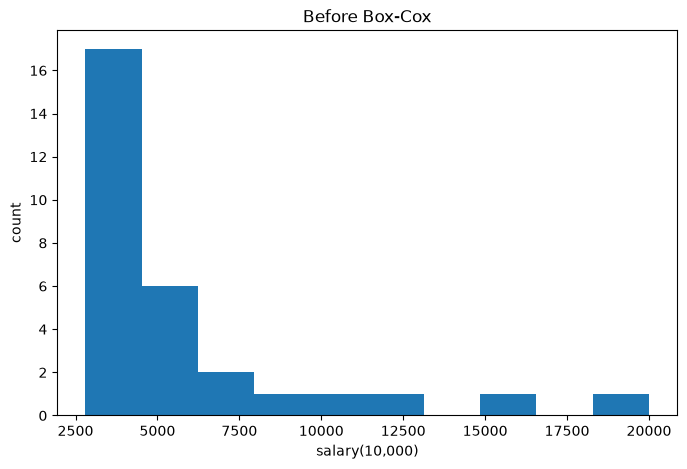

In [1]:
# Box-Cox: 1964년에 제안된 변환 방법으로, 양수 데이터만 처리할 수 있다.
# Yeo-Johnson: 2000년에 제안된 변환 방법으로, Box-Cox와 비슷한 목적을 가지면서
# 0과 음수 데이터도 처리할 수 있도록 확장한 방법이다.
# 다음의 salary 데이터 변수는 양수만 존재하므로 두방법이 동일한 결과를 만든다

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import PowerTransformer


# 1. 30명의 직장인 연봉 데이터
df = pd.DataFrame({
    'salary': [
        2800, 2900, 3000, 3100, 3200,
        3300, 3400, 3500, 3600, 3700,
        3800, 3900, 4000, 4100, 4200,
        4300, 4500, 4700, 4900, 5200,
        5500, 5800, 6200, 6800, 7500,
        8500, 10000, 12000, 15000, 20000
    ]
})

# display(df)


# 2. 변환 전 데이터 탐색
print("평균 :", df['salary'].mean())
print("중앙값 :", df['salary'].median())


# 3. 변환 전 히스토그램
plt.figure(figsize=(8, 5))

plt.hist(df['salary'], bins=10)

plt.xlabel('salary(10,000)')
plt.ylabel('count')
plt.title('Before Box-Cox')

plt.show()


In [2]:
# 4. Box-Cox 변환
pt = PowerTransformer(method='box-cox')
# pt = PowerTransformer(method='yeo-johnson')

salary_boxcox = pt.fit_transform(df[['salary']])


# 변환 결과를 새로운 컬럼으로 추가
df['salary_boxcox'] = salary_boxcox

In [3]:
# 5. 변환 후 데이터 탐색
display(df)


,salary,salary_boxcox
0,2800,-1.707895
1,2900,-1.543160
2,3000,-1.390453
3,3100,-1.248537
4,3200,-1.116338
5,3300,-0.992917
6,3400,-0.877450
7,3500,-0.769213
8,3600,-0.667566
9,3700,-0.571940


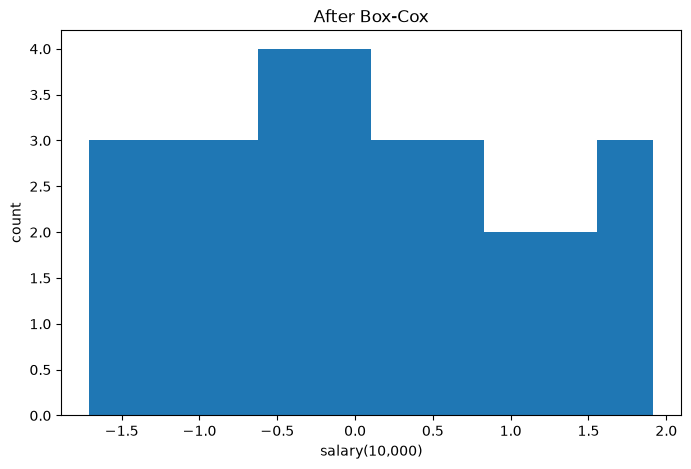

In [4]:
# 6. 변환 후 히스토그램
plt.figure(figsize=(8, 5))

plt.hist(df['salary_boxcox'], bins=10)

plt.xlabel('salary(10,000)')
plt.ylabel('count')
plt.title('After Box-Cox')

plt.show()

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PowerTransformer
from sklearn.metrics import r2_score


# 1. 실제 샘플 데이터 정의 (NumPy 사용 X)
df = pd.DataFrame({
    'X1': [
        1.1, 1.2, 1.3, 1.5, 1.8, 2.0, 2.3, 2.7, 3.0, 3.5,
        4.0, 5.2, 6.8, 9.0, 12.5, 18.0, 25.0, 40.0, 75.0, 150.0,
        1.0, 1.4, 1.6, 2.1, 2.5, 3.2, 4.5, 7.5, 15.0, 35.0,
        1.2, 1.7, 2.2, 2.9, 3.8, 5.5, 8.5, 20.0, 50.0, 110.0
    ],
    'X2': [
        0.5, 0.8, 1.1, 1.4, 2.0, 2.5, 3.2, 4.0, 5.5, 7.0,
        10.0, 14.0, 22.0, 35.0, 60.0, 95.0, 140.0, 230.0, 400.0, 800.0,
        0.6, 1.0, 1.3, 1.8, 2.8, 4.8, 8.0, 18.0, 45.0, 100.0,
        0.7, 1.2, 1.9, 3.0, 5.0, 9.0, 16.0, 30.0, 80.0, 200.0
    ],
    'y': [
        12.1, 13.5, 14.2, 15.8, 17.1, 18.3, 19.5, 21.0, 22.4, 24.1,
        25.8, 28.2, 31.0, 34.2, 37.9, 41.5, 45.1, 50.3, 57.8, 66.2,
        11.5, 15.1, 16.2, 18.7, 20.5, 23.0, 27.1, 32.5, 39.1, 48.0,
        13.0, 16.5, 19.0, 21.8, 24.9, 28.8, 33.0, 42.1, 52.0, 62.5
    ]
})

In [6]:
# 2. X, y 분리 및 학습 / 테스트 데이터 분리
X = df[['X1', 'X2']]
y = df['y']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [7]:
# 3. 원본 데이터 → 선형회귀(LinearRegression)
print("\n===== 1. 원본 데이터 (LinearRegression) =====")

lr = LinearRegression()
lr.fit(X_train, y_train)
print("기울기 a :", lr.coef_)
print("절편 b :", lr.intercept_)

pred_lr = lr.predict(X_test)

r2_original = r2_score(y_test, pred_lr)

print("결정계수 R² :", round(r2_original, 4))


===== 1. 원본 데이터 (LinearRegression) =====
기울기 a : [ 0.82539962 -0.03674495]
절편 b : 18.77994305448621
결정계수 R² : -0.5109


In [8]:
# 4. Yeo-Johnson 변환
pt = PowerTransformer(method='yeo-johnson')

X_train_yj = pt.fit_transform(X_train)
X_test_yj = pt.transform(X_test)

In [9]:
# 5. Yeo-Johnson 변환 후 → 선형회귀(LinearRegression)
print("\n===== 2. Yeo-Johnson 변환 후 (LinearRegression) =====")

lr_yj = LinearRegression()
lr_yj.fit(X_train_yj, y_train)
print("기울기 a :", lr_yj.coef_)
print("절편 b :", lr_yj.intercept_)


===== 2. Yeo-Johnson 변환 후 (LinearRegression) =====
기울기 a : [17.25065835 -4.69453564]
절편 b : 26.05714285714285


In [10]:
pred_yj = lr_yj.predict(X_test_yj)

r2_yj = r2_score(y_test, pred_yj)

print("결정계수 R² :", round(r2_yj, 4))

결정계수 R² : 0.8291


In [11]:
# 6. [추가] 분포 변환 전/후 히스토그램 비교 
# 변환 후 데이터를 보기 편하게 DataFrame으로 변환
X_train_yj_df = pd.DataFrame(X_train_yj, columns=['X1', 'X2'])

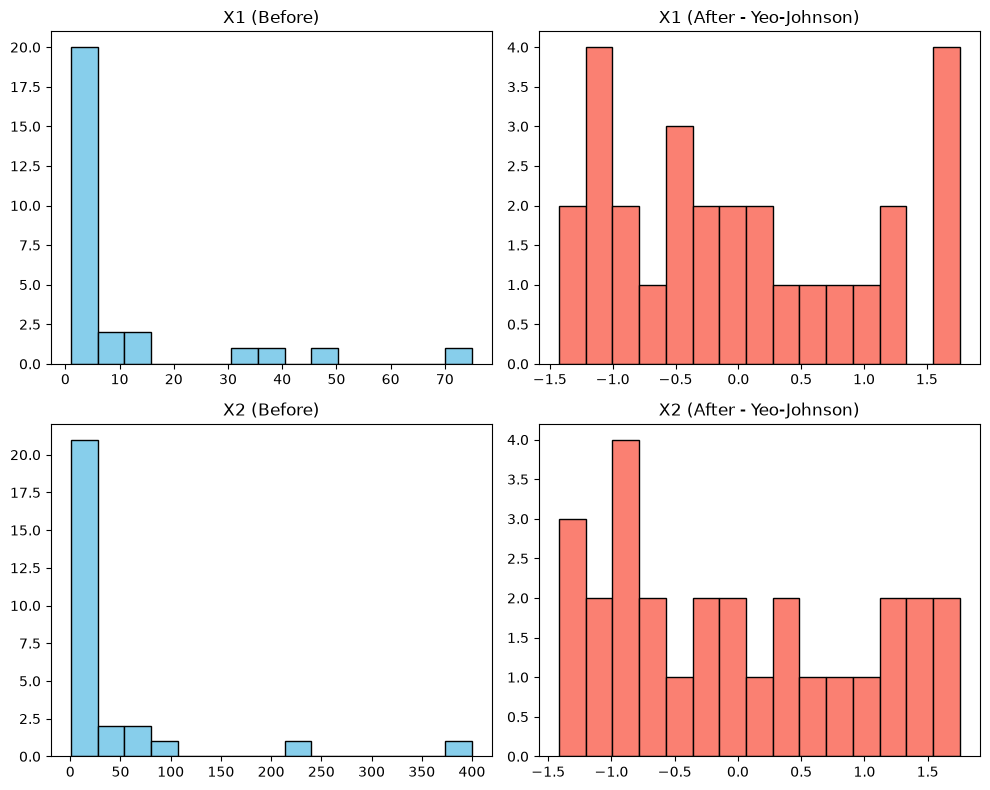

In [12]:
# 시각화
fig = plt.figure(figsize=(10, 8))

axes1 = fig.add_subplot(2, 2, 1)
axes2 = fig.add_subplot(2, 2, 2)
axes3 = fig.add_subplot(2, 2, 3)
axes4 = fig.add_subplot(2, 2, 4)

# X1 변환 전/후
axes1.hist(X_train['X1'], bins=15, color='skyblue', edgecolor='black')
axes1.set_title('X1 (Before)')

axes2.hist(X_train_yj_df['X1'], bins=15, color='salmon', edgecolor='black')
axes2.set_title('X1 (After - Yeo-Johnson)')

# X2 변환 전/후
axes3.hist(X_train['X2'], bins=15, color='skyblue', edgecolor='black')
axes3.set_title('X2 (Before)')

axes4.hist(X_train_yj_df['X2'], bins=15, color='salmon', edgecolor='black')
axes4.set_title('X2 (After - Yeo-Johnson)')

plt.tight_layout()
plt.show()

45) sklearn 전처리 - 변수변환(스케일링)

1. 스케일링

- 스케일링은 변수들의 숫자 크기나 범위를 비슷한 기준으로 맞추는 전처리 방법이다.
- 스케일링에는 여러 방법이 있으며, 표준화(Standardization)는 그중 하나다.

1) 스케일링은 언제? <br>
스케일링은 모든 데이터에 무조건 적용하는 전처리가 아니라, 알고리즘의 특성과 데이터의 변수 단위를 보고 적용한다.



| 알고리즘 | 스케일링 |
|---|---|
| KNN | **중요** |
| K-means | **중요** |
| SVM | **중요** |
| 신경망 | 권장 |
| 선형회귀 | 상황에 따라 |
| 로지스틱 회귀 | 상황에 따라 |
| Decision Tree | 보통 불필요 |
| Random Forest | 보통 불필요 |
| XGBoost | 보통 불필요 |

2) 대표적인 스케일링 방법

| 방법 | 설명 | 대표적인 sklearn |
|---|---|---|
| **표준화** | 평균 0, 표준편차 1을 기준으로 변환 | `StandardScaler` |
| 정규화 | 일정한 범위(주로 0~1)로 변환 | `MinMaxScaler` |
| 로버스트 스케일링 | 중앙값과 IQR을 이용해 이상치의 영향을 줄임 | `RobustScaler` |

#### 표준화 공식
- z = 데이터값 - 평균 / 표준편차
- 표준편차는 데이터가 평균에서 일반적으로 얼마나 떨어져 있는지를 나타내는 값
- 따라서 Z-score 는 "현재 데이터의 평균과 거리 / 평균 떨어진 거리" -> 현재 데이터가 평균에서 표준편차의 몇 배만큰 떨어져 있는가?가 된다. 
- 어떤 값이 평균에서 표준편차의 몇배만큼 떨어져 있는가?


Z-score가 <br>
1. 0이면 평균과 같다
2. 1이면 평균에서 표준편차 만큼 크다(떨어져 있다)
3. 2이면 평균에서 표준편차의 2배만큼 크다(떨어져 있다)
4. -1이면  평균에서 표준편차 만큼 작다(떨어져 있다)
5. -2이면 평균에서 표준편차의 2배만큼 작다(떨어져 있다)


예시
1. 400, 500, 600 에서 600은 평균500에서 표준편차100의 1배 크다. -> 평균500을 0으로 마추면 Z-score는 -1, 0, 1
2. 4, 5, 6 에서 6은 평균5에서 표준편차1의 1배 크다. -> 평균5을 0으로 마추면 Z-score는 -1, 0, 1
3. Z-score는 숫자의 크기/단위가 달라도 평균에서 얼마나 떨어져 있는지를 표준편차 단위로 바꾸면 똑같이 -1, 0, +1이 된다

3) 표준화 Z 실습

- 다음의 데이터에 대해서 "연봉"변수, "나이"변수에 10%라는 동일한 변화인데도 원래 숫자의 크기가 다르기 때문에 KNN의 거리에서 전혀 다르게 나타나는 문제를 보여주면 된다.
- 변화율은 동일한데 변수의 단위와 숫자 크기가 다르기 때문에 거리 계산에서는 서로 다른 영향력을 갖게 된다.
- 그래서 KNN 같은 거리 기반 알고리즘에서는 스케일링이 중요하다.

연봉(원) → 숫자가 매우 큼 <br>
나이(세) → 숫자가 작음 <br>
       ↓ <br>
거리 계산 <br>
       ↓ <br>
연봉의 영향이 지나치게 커짐 <br>
       ↓ <br>
표준화(StandardScaler) <br>
       ↓ <br>
변수들의 스케일을 비슷하게 맞춤 <br>

In [14]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

df = pd.DataFrame({
    "키(cm)": [160, 170, 180],
    "연봉(원)": [50_000_000, 60_000_000, 80_000_000],
    "나이(세)": [30, 40, 50]
})
display(df)

# 문제점) 
# 첫번째 데이터의 연봉이 10%로 올라 55,000,000된것과
# 나이가 10% 올라 33세된것을 같은 변화로 처리해야 하지만
# KNN 같은 거리 기반의 알고리즘의 경우 거리를 계산해 보면
# 연봉이 오른 변화는 (55,000,000 - 50,000,000)의 제곱 + (30-30)의 제곱의 루트는 5,000,000
# 나이가 오른 변화는 (50,000,000 - 50,000,000)의 제곱 + (33-30)의 제곱의 루트는 3 
# 변화율은 동일한데 변수의 단위와 숫자 크기가 다르기 때문에 거리 계산에서는 서로 다른 영향력을 갖게 된다.

# 스케일링 방법 중 표준화 scikit-learn 라이브러리 사용 X
mean = df.mean()
std = df.std(ddof=0)   # 모집단 표준편차
# df.std(ddof=1)   # 표본 표준편차
df_scaled = (df - mean) / std
display(df_scaled)

# scikit-learn 라이브러리 사용
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)
df_scaled = pd.DataFrame(
    df_scaled,
    columns=df.columns
)
display(df_scaled)

,키(cm),연봉(원),나이(세)
0,160,50000000,30
1,170,60000000,40
2,180,80000000,50


,키(cm),연봉(원),나이(세)
0,-1.224745,-1.069045,-1.224745
1,0.000000,-0.267261,0.000000
2,1.224745,1.336306,1.224745


,키(cm),연봉(원),나이(세)
0,-1.224745,-1.069045,-1.224745
1,0.000000,-0.267261,0.000000
2,1.224745,1.336306,1.224745


4) 정규화 실습
- 정규화는 최솟값을 0, 최댓값을 1로 맞추고, 나머지 값은 최소~최대 범위에서 차지하는 비율로 변환하는 방법이다.
- Min-Max 정규화는 최댓값과 최솟값을 기준으로 변환하기 때문에 이상치가 있으면 전체 데이터의 변환 결과가 영향을 받는다.



In [15]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

X_scaled = scaler.fit_transform(X)

5) 로버스트 스케일링 실습
- RobustScaler는 중앙값과 IQR을 사용해 이상치의 영향을 줄이는 스케일링 방법이다.
- 어떤 값이 중앙값에서 IQR의 몇 배만큼 떨어져 있는가?


In [16]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()

X_scaled = scaler.fit_transform(X)

MinMaxScaler <br>
→ 최소값, 최대값 사용 <br>
→ 이상치에 민감 <br>

<br>

StandardScaler <br>
→ 평균, 표준편차 사용 → 어떤 값이 평균에서 표준편차의 몇배만큼 떨어져 있는가? <br>
→ 이상치의 영향을 받음 <br>

<br>

RobustScaler <br>
→ 중앙값, IQR 사용 → 어떤 값이 중앙값에서 IQR의 몇 배만큼 떨어져 있는가? <br>
→ 이상치의 영향을 상대적으로 덜 받음 <br>

표준화 vs 로버스트 vs 정규화

In [ ]:
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import MinMaxScaler


df = pd.DataFrame({
    "키(cm)": [160, 170, 180],
    "연봉(원)": [50_000_000, 60_000_000, 80_000_000],
    "나이(세)": [30, 40, 50]
})

display(df)

,키(cm),연봉(원),나이(세)
0,160,50000000,30
1,170,60000000,40
2,180,80000000,50


In [18]:
# 1. 표준화(StandardScaler)
# 평균 → 0
# 표준편차 → 1
print('1. 표준화(StandardScaler)')
scaler = StandardScaler()

df_standard = scaler.fit_transform(df)

df_standard = pd.DataFrame(
    df_standard,
    columns=df.columns
)

display(df_standard)

1. 표준화(StandardScaler)


,키(cm),연봉(원),나이(세)
0,-1.224745,-1.069045,-1.224745
1,0.000000,-0.267261,0.000000
2,1.224745,1.336306,1.224745


In [19]:
# 2. 로버스트 스케일링(RobustScaler)
# 중앙값 → 0
# IQR을 기준으로 변환
print('2. 로버스트 스케일링(RobustScaler)')
scaler = RobustScaler()

df_robust = scaler.fit_transform(df)

df_robust = pd.DataFrame(
    df_robust,
    columns=df.columns
)

display(df_robust)

2. 로버스트 스케일링(RobustScaler)


,키(cm),연봉(원),나이(세)
0,-1.0,-0.666667,-1.0
1,0.0,0.000000,0.0
2,1.0,1.333333,1.0


In [20]:
# 3. 정규화(MinMaxScaler)
# 최솟값 → 0
# 최댓값 → 1
print('3. 정규화(MinMaxScaler)')
scaler = MinMaxScaler()

df_minmax = scaler.fit_transform(df)

df_minmax = pd.DataFrame(
    df_minmax,
    columns=df.columns
)

display(df_minmax)

3. 정규화(MinMaxScaler)


,키(cm),연봉(원),나이(세)
0,0.0,0.000000,0.0
1,0.5,0.333333,0.5
2,1.0,1.000000,1.0
